In [1]:
from pathlib import Path
import os
folder = Path("./low-code-localization/artifacts/04-Added_automl_model/") 
stages = [file.replace("_usage.pkl", "") for file in os.listdir(folder) if os.path.isfile(folder/file) and file.endswith("_usage.pkl")]
stages

['gridsearch_spring-RandomForestRegressor-RandomSplit-results',
 'split_spring-KFoldSplit',
 'prepare_winter',
 'gridsearch_spring-KNeighborsRegressor-RandomSplit-results',
 'featurize_spring',
 'split_spring-RandomSplit',
 'featurize_winter',
 'automl_spring-ExampleModel-RandomSplit-results',
 'gridsearch_spring-RandomForestRegressor-KFoldSplit-results',
 'prepare_spring',
 'gridsearch_winter-RandomForestRegressor-RandomSplit-results',
 'automl_winter-ExampleModel-RandomSplit-results',
 'gridsearch_spring-KNeighborsRegressor-KFoldSplit-results',
 'automl_spring-ExampleModel-KFoldSplit-results',
 'automl_winter-ExampleModel-KFoldSplit-results',
 'gridsearch_winter-RandomForestRegressor-KFoldSplit-results',
 'gridsearch_winter-KNeighborsRegressor-RandomSplit-results',
 'split_winter-RandomSplit',
 'split_winter-KFoldSplit',
 'gridsearch_winter-KNeighborsRegressor-KFoldSplit-results']

In [2]:
from collections import defaultdict
import pandas as pd
import joblib

grouped_dfs = defaultdict(list)

for fname in stages:
    prefix = fname.split("_", 1)[0]
    filepath = os.path.join(folder, f"{fname}_usage.pkl")
    
    df = joblib.load(filepath)
    grouped_dfs[prefix].append(df)

for prefix, dfs in grouped_dfs.items():
    for i in range(1, len(dfs)):
        print(f"{dfs[i]['t'].iloc[0]:5.1f} s|{dfs[i]['t'].iloc[-1]:5.1f} s:", end=" –> ")
        dfs[i]["t"] += dfs[i-1]["t"].iloc[-1]
        print(f"{dfs[i]['t'].iloc[0]:5.1f} s|{dfs[i]['t'].iloc[-1]:5.1f} s:")
        
    combined_df = pd.concat(dfs, ignore_index=True)
    output_file = os.path.join("./", f"{prefix}_usage.pkl")
    joblib.dump(combined_df, output_file)
    print(f"Saved {output_file} with {len(combined_df)} rows")

print("All grouped DataFrames have been combined and saved!")

  0.0 s|493.4 s: –> 18307.8 s|18801.3 s:
  0.0 s|13030.1 s: –> 18801.3 s|31831.4 s:
  0.0 s|841.9 s: –> 31831.4 s|32673.2 s:
  0.0 s|48205.7 s: –> 32673.2 s|80879.0 s:
  0.0 s|898.1 s: –> 80879.0 s|81777.1 s:
  0.0 s|790.0 s: –> 81777.1 s|82567.1 s:
  0.0 s|791.0 s: –> 82567.1 s|83358.1 s:
Saved ./gridsearch_usage.pkl with 833389 rows
  0.0 s|  1.4 s: –>   1.3 s|  2.7 s:
  0.0 s|  0.1 s: –>   2.7 s|  2.8 s:
  0.0 s|  0.1 s: –>   2.8 s|  2.9 s:
Saved ./split_usage.pkl with 37 rows
  0.0 s| 16.8 s: –>   1.8 s| 18.6 s:
Saved ./prepare_usage.pkl with 190 rows
  0.0 s|  0.1 s: –>   2.6 s|  2.7 s:
Saved ./featurize_usage.pkl with 31 rows
  0.0 s|233.3 s: –> 11931.5 s|12164.8 s:
  0.0 s|1096.3 s: –> 12164.8 s|13261.1 s:
  0.0 s|1134.1 s: –> 13261.1 s|14395.2 s:
Saved ./automl_usage.pkl with 143960 rows
All grouped DataFrames have been combined and saved!


In [3]:
from pathlib import Path
results_dir = Path(".")
stages      = ["prepare", "featurize", "split", "gridsearch", "automl"]

prepare 
           t  cpu_cores      ram_mb
0  0.000000      0.987  221.007812
1  0.001113      0.000  221.007812
2  0.100834      1.000  198.195312
3  0.201098      0.996  200.406250
4  0.301261      0.998  200.480469
featurize 
           t  cpu_cores      ram_mb
0  0.000000      0.891  215.339844
1  0.000920      0.000  215.339844
2  0.100619      1.002  215.339844
3  0.200671      1.000  215.339844
4  0.300684      1.000  215.597656
split 
           t  cpu_cores      ram_mb
0  0.000000      1.090  194.742188
1  0.000815      0.000  194.742188
2  0.100606      1.002  194.742188
3  0.200629      1.000  194.742188
4  0.300675      0.999  194.886719
gridsearch 
           t  cpu_cores      ram_mb
0  0.000000      0.959  195.136719
1  0.000697      0.000  195.140625
2  0.100640      1.000  277.675781
3  0.200623      1.100  286.695312
4  0.300868      0.898  431.828125
automl 
           t  cpu_cores      ram_mb
0  0.000000      0.992  202.203125
1  0.000720      0.000  202.203125
2  

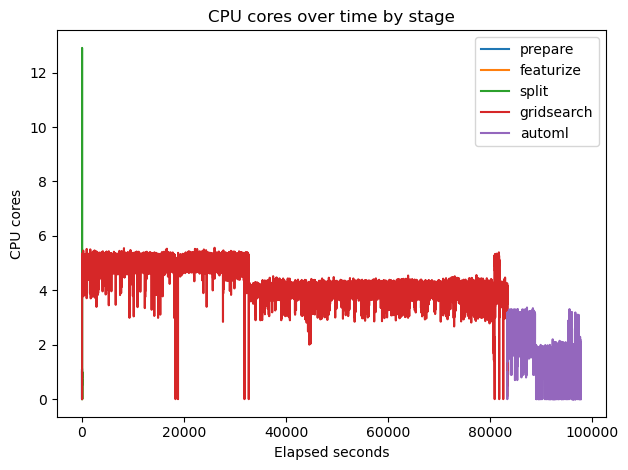

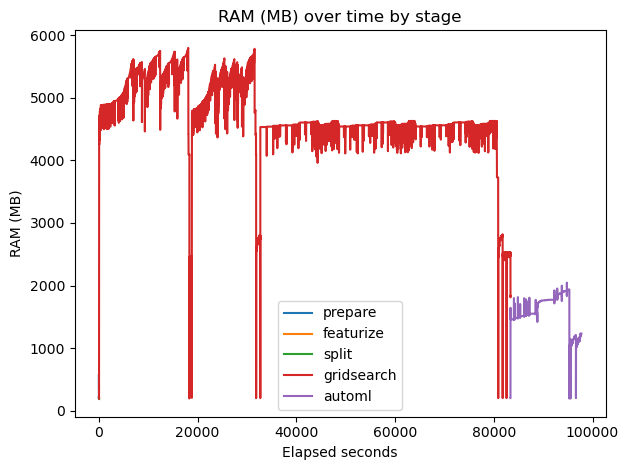

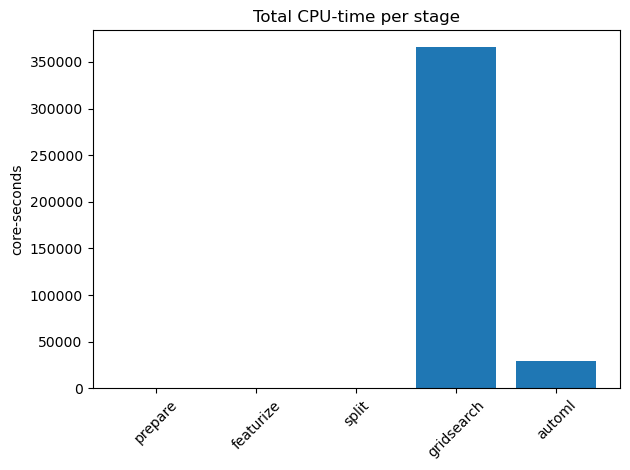

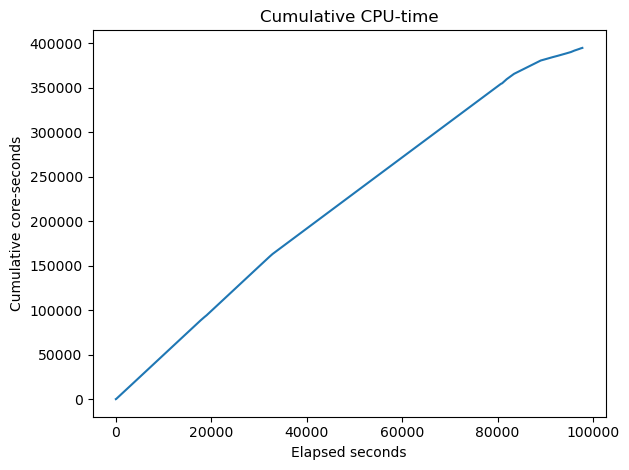

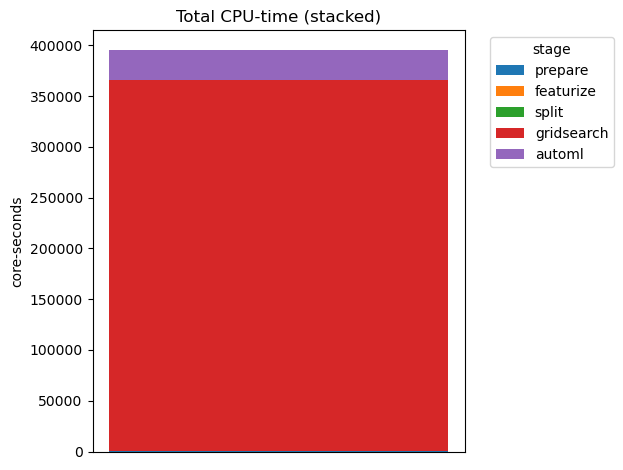

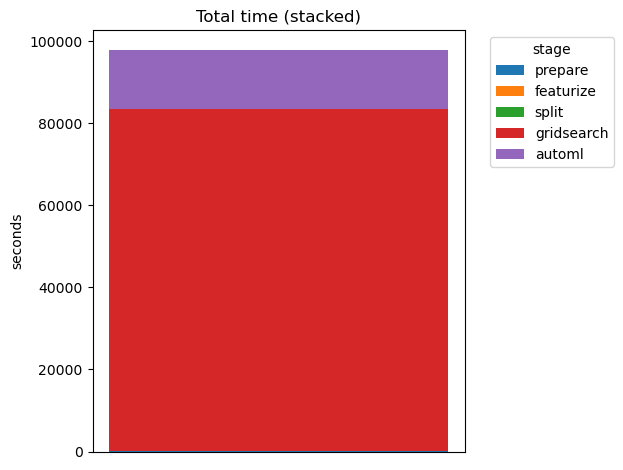

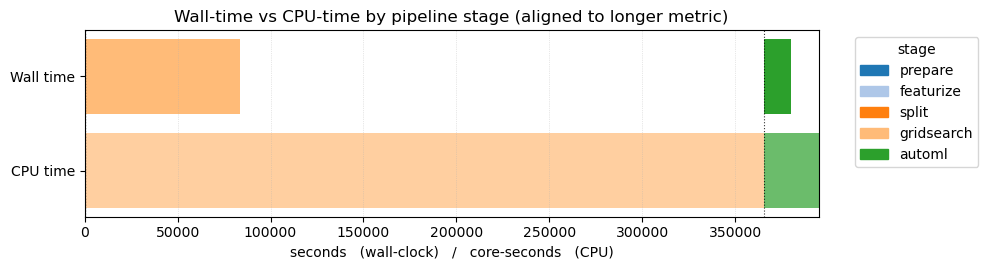

In [4]:
import joblib, pandas as pd, numpy as np, matplotlib.pyplot as plt

dfs    = []
offset = 0.0

for stage in stages:
    p = results_dir / f"{stage}_usage.pkl"
    if not p.exists():
        print(f"missing: {p}")
        continue

    df = joblib.load(p)
    print(stage, "\n", df.head())

    df["elapsed"]   = df["t"] + offset
    offset = df["elapsed"].iloc[-1]
    df["stage"] = stage
    dfs.append(df)

if not dfs:
    raise RuntimeError("No usable usage files found.")

usage = pd.concat(dfs, ignore_index=True)

# ------------------------------------------------------------
# 1) CPU-cores & RAM lines
# ------------------------------------------------------------
for metric, ylabel in [("cpu_cores", "CPU cores"), ("ram_mb", "RAM (MB)")]:
    plt.figure()
    for stage in stages:
        sub = usage[usage["stage"] == stage]
        if not sub.empty:
            plt.plot(sub["elapsed"], sub[metric], label=stage)
    plt.xlabel("Elapsed seconds")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} over time by stage")
    plt.legend(); plt.tight_layout()

# ------------------------------------------------------------
# 2) CPU-time (core-seconds)
# ------------------------------------------------------------
# integrate cpu_cores over elapsed time, stage-by-stage
cpu_secs = []
for stage in stages:
    sub = usage[usage["stage"] == stage]
    if sub.empty:
        continue
    secs = np.trapz(sub["cpu_cores"].values, sub["elapsed"].values)   # core-seconds
    cpu_secs.append((stage, secs))

cpu_df = pd.DataFrame(cpu_secs, columns=["stage", "core_seconds"])

# bar chart – total CPU-time per stage
plt.figure()
plt.bar(cpu_df["stage"], cpu_df["core_seconds"])
plt.ylabel("core-seconds")
plt.title("Total CPU-time per stage")
plt.xticks(rotation=45)
plt.tight_layout()

# cumulative curve – running core-seconds over whole run
usage_sorted = usage.sort_values("elapsed").copy()
usage_sorted["delta_t"]       = usage_sorted["elapsed"].diff().fillna(0)
usage_sorted["core_seconds"]  = usage_sorted["cpu_cores"] * usage_sorted["delta_t"]
usage_sorted["cumulative_cs"] = usage_sorted["core_seconds"].cumsum()

plt.figure()
plt.plot(usage_sorted["elapsed"], usage_sorted["cumulative_cs"])
plt.xlabel("Elapsed seconds")
plt.ylabel("Cumulative core-seconds")
plt.title("Cumulative CPU-time")
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 3) stacked bars – CPU-time (core-seconds) AND time
# ------------------------------------------------------------
import numpy as np

# ---------- per-stage aggregates ----------
cpu_secs   = []   # core-seconds
time_secs  = []   # seconds

for stage in stages:
    sub = usage[usage["stage"] == stage]
    if sub.empty:
        continue

    # CPU-time  = intgral cpu_cores dt
    cpu = np.trapz(sub["cpu_cores"].values, sub["elapsed"].values)
    cpu_secs.append(cpu)

    time = sub["elapsed"].iloc[-1] - sub["elapsed"].iloc[0]
    time_secs.append(time)

labels = stages

# ---------- stacked CPU-time ----------
plt.figure()
bottom = 0
for stage, val in zip(labels, cpu_secs):
    plt.bar(0, val, bottom=bottom, label=stage)
    bottom += val
plt.ylabel("core-seconds")
plt.title("Total CPU-time (stacked)")
plt.xticks([])  # single stacked bar, no x-tick needed
plt.legend(title="stage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# ---------- stacked time ----------
plt.figure()
bottom = 0
for stage, val in zip(labels, time_secs):
    plt.bar(0, val, bottom=bottom, label=stage)
    bottom += val
plt.ylabel("seconds")
plt.title("Total time (stacked)")
plt.xticks([])
plt.legend(title="stage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

# ------------------------------------------------------------------
# 4) stacked bars — aligned to the longer of the two metrics 
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ---- gather per-stage aggregates ----
labels, cpu_secs, time_secs = [], [], []
for stage in stages:
    sub = usage[usage["stage"] == stage]
    if sub.empty:
        continue
    cpu  = np.trapz(sub["cpu_cores"].values, sub["elapsed"].values)          # core-seconds
    time = sub["elapsed"].iloc[-1] - sub["elapsed"].iloc[0]                  # seconds
    labels.append(stage)
    cpu_secs.append(cpu)
    time_secs.append(time)

if not labels:
    raise RuntimeError("No stages loaded, cannot plot stacked bars.")

# ---- colour palette ----
palette = plt.cm.tab20.colors
cmap    = {stage: palette[i % len(palette)] for i, stage in enumerate(labels)}

# ---- left offsets: cumulative max(cpu, time) ----
max_len       = [max(c, w) for c, w in zip(cpu_secs, time_secs)]
left_offsets  = np.concatenate(([0], np.cumsum(max_len[:-1])))

# ---- plot ----
fig, ax = plt.subplots(figsize=(10, 2.8))

# row: CPU-time  (core-seconds)
for stage, width, left in zip(labels, cpu_secs, left_offsets):
    ax.barh("CPU time", width, left=left, color=cmap[stage], alpha=0.7, edgecolor="none")

# row: time
for stage, width, left in zip(labels, time_secs, left_offsets):
    ax.barh("Wall time", width, left=left, color=cmap[stage], edgecolor="none")

# ---- vertical lines at each stage start (except t=0) ----
for x in left_offsets[1:]:
    ax.axvline(x, color="k", linestyle=":", linewidth=0.8, alpha=0.8)

# ---- cosmetics ----
ax.set_xlabel("seconds   (wall-clock)   /   core-seconds   (CPU)")
ax.set_title("Wall-time vs CPU-time by pipeline stage (aligned to longer metric)")
ax.set_yticks(["CPU time", "Wall time"])
ax.set_xlim(0, left_offsets[-1] + max_len[-1])
ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.6)

# legend showing stage colors
handles = [plt.Rectangle((0,0),1,1, color=cmap[s]) for s in labels]
ax.legend(handles, labels, title="stage", bbox_to_anchor=(1.04, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [5]:
df

,t,cpu_cores,ram_mb,elapsed,stage
0,0.000000,0.992,202.203125,83382.296654,automl
1,0.000720,0.000,202.203125,83382.297373,automl
2,0.100898,0.894,284.542969,83382.397552,automl
3,0.201386,1.095,436.027344,83382.498039,automl
4,0.301385,0.905,444.722656,83382.598039,automl
...,...,...,...,...,...
143955,14394.812432,1.001,1227.917969,97777.109086,automl
143956,14394.912429,1.000,1227.917969,97777.209083,automl
143957,14395.012407,1.000,1227.917969,97777.309061,automl
143958,14395.112404,0.900,1228.375000,97777.409058,automl
